# 04 — Temporal Fault Localisation

## Goal
Go beyond binary detection — **predict the exact position** of the blockage
within the pipe.

This is the key differentiator of this project. Simple anomaly detection tells you
*something is wrong*. Localisation tells you *where to dig*.

## Approach
We train a **1-D CNN regression model** on raw normalised waveforms.
The network must learn to identify the echo arrival time and translate it to a
blockage position — effectively learning the physics of acoustic round-trip delay.

We also compare against:
1. **Classical DSP localisation** — peak detection → echo time → position formula
2. **Ablation study** — effect of SNR on localisation accuracy

**Evaluation metric**: Mean Absolute Error (MAE) in normalised position units
and converted to metres for a reference 30 m pipe.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

from src.models      import BlockageLocaliser, train_localiser
from src.simulation  import AcousticPipeSimulator, PipeConfig, Blockage, echo_time_to_position
from src.features    import detect_echo_peaks

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

signals   = np.load('../data/signals.npy')
labels    = np.load('../data/labels.npy')
positions    = np.load('../data/positions.npy')
pipe_lengths = np.load('../data/pipe_lengths.npy')    # (N, max_blockages), -1 = absent
sigs_norm = np.load('../outputs/features/signals_norm.npy')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Loaded dataset. Device: {device}')

Loaded dataset. Device: cpu


## 4.1 Prepare Single-Blockage Subset

For a clean regression task we first train on signals with **exactly one blockage**.
The target is the normalised blockage position in [0, 1].

Single-blockage samples : 487
Position range          : [0.025, 0.979]


DSP physics positions: 487/487 valid


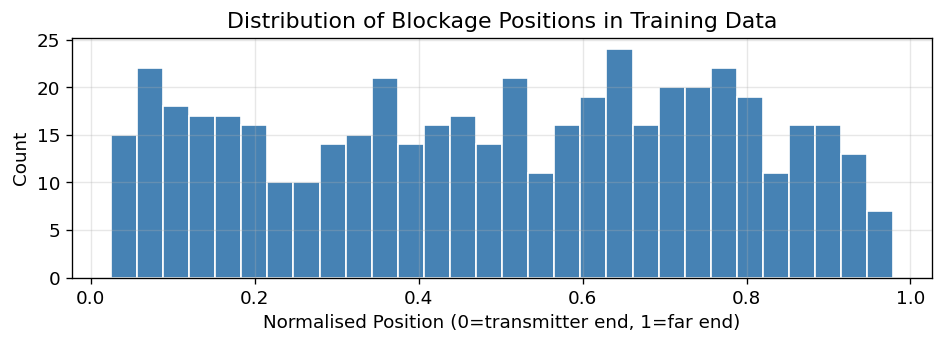

In [2]:
# Find signals with exactly one blockage
n_blockages = (positions > -0.5).sum(axis=1)  # count non-padding entries
single_mask = n_blockages == 1

sigs_1blk = sigs_norm[single_mask]            # normalised waveforms
pos_1blk  = positions[single_mask, 0]         # primary blockage position (normalised)

print(f'Single-blockage samples : {single_mask.sum()}')
print(f'Position range          : [{pos_1blk.min():.3f}, {pos_1blk.max():.3f}]')

# Pre-compute DSP physics positions for physics consistency loss
from src.features import detect_echo_peaks
FS_local, V_local = 44_100, 343.0
plen_1blk     = pipe_lengths[single_mask]
raw_1blk      = signals[single_mask]
physics_pos_1blk = np.full(len(sigs_1blk), -1.0, dtype=np.float32)
for _i, (_sig, _plen) in enumerate(zip(raw_1blk, plen_1blk)):
    _pt, _ = detect_echo_peaks(_sig, fs=FS_local, min_prominence=0.03)
    if len(_pt) > 0:
        _pos_m = _pt[0] * V_local / 2.0
        physics_pos_1blk[_i] = float(np.clip(_pos_m / _plen, 0.0, 1.0))
_n_valid = (physics_pos_1blk >= 0).sum()
print(f'DSP physics positions: {_n_valid}/{len(sigs_1blk)} valid')

# Distribution of blockage positions
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(pos_1blk, bins=30, color='steelblue', edgecolor='white')
ax.set(xlabel='Normalised Position (0=transmitter end, 1=far end)',
       ylabel='Count', title='Distribution of Blockage Positions in Training Data')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/04_position_distribution.png', bbox_inches='tight')
plt.show()

## 4.2 Train the 1-D CNN Localiser

In [3]:
localiser, history = train_localiser(
    signals=sigs_1blk,
    positions=pos_1blk,
    physics_positions=physics_pos_1blk,
    physics_lambda=0.1,
    epochs=30,
    batch_size=64,
    lr=1e-3,
    val_split=0.2,
    save_path='../outputs/models/localiser.pth',
    device=device,
)

Physics consistency loss: lambda=0.1  DSP-valid training samples=390/390


Epoch   1/30  train_loss=0.08969  val_loss=0.04753  val_MAE=0.1805  physics_MAE=0.1834


Epoch   5/30  train_loss=0.03645  val_loss=0.02138  val_MAE=0.1170  physics_MAE=0.1200


Epoch  10/30  train_loss=0.03419  val_loss=0.02431  val_MAE=0.1273  physics_MAE=0.1303


Epoch  15/30  train_loss=0.03257  val_loss=0.02440  val_MAE=0.1211  physics_MAE=0.1240


Epoch  20/30  train_loss=0.02479  val_loss=0.02692  val_MAE=0.1234  physics_MAE=0.1262


Epoch  25/30  train_loss=0.02113  val_loss=0.02927  val_MAE=0.1284  physics_MAE=0.1312


Epoch  30/30  train_loss=0.02132  val_loss=0.02875  val_MAE=0.1271  physics_MAE=0.1299
Model saved -> ../outputs/models/localiser.pth


## 4.3 Training Curves

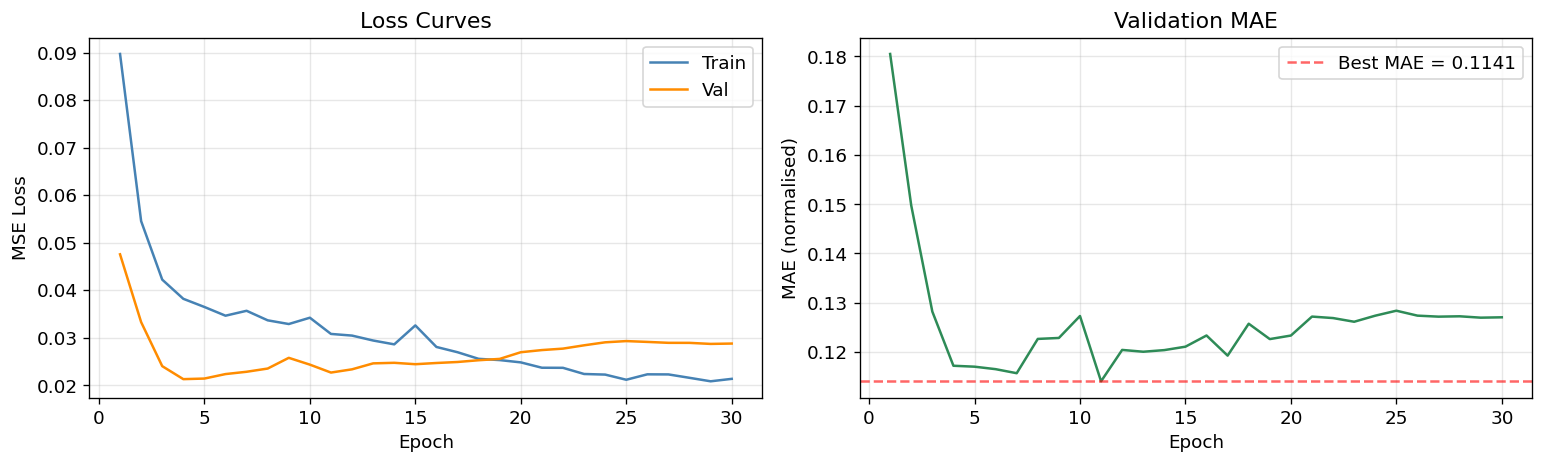

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='darkorange')
axes[0].set(xlabel='Epoch', ylabel='MSE Loss', title='Loss Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_mae'], color='seagreen')
axes[1].axhline(min(history['val_mae']), color='red', linestyle='--', alpha=0.6,
                label=f'Best MAE = {min(history["val_mae"]):.4f}')
axes[1].set(xlabel='Epoch', ylabel='MAE (normalised)', title='Validation MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/04_localiser_curves.png', bbox_inches='tight')
plt.show()

## 4.4 Predicted vs. True Position (Scatter Plot)

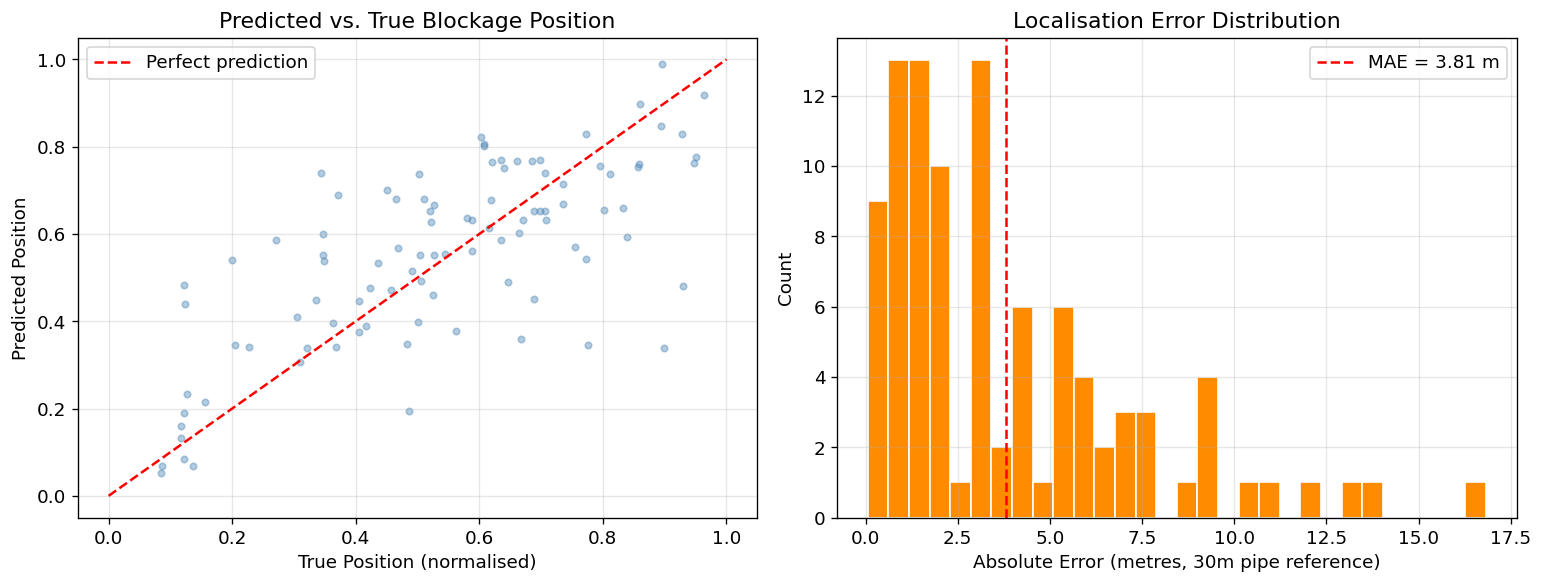

CNN Localiser — MAE (normalised): 0.1271
CNN Localiser — MAE (metres, 30m pipe): 3.81 m


In [5]:
# Rebuild val split
X_all = torch.tensor(sigs_1blk[:, np.newaxis, :], dtype=torch.float32)
y_all = torch.tensor(pos_1blk[:, np.newaxis],     dtype=torch.float32)
dataset = TensorDataset(X_all, y_all)
n_val   = int(0.2 * len(dataset))
n_train = len(dataset) - n_val
_, val_ds = random_split(dataset, [n_train, n_val],
                          generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_ds, batch_size=128)

localiser.eval()
preds_list, true_list = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        p = localiser(xb.to(device)).cpu().numpy().flatten()
        preds_list.extend(p)
        true_list.extend(yb.numpy().flatten())

preds_arr = np.array(preds_list)
true_arr  = np.array(true_list)
errors    = np.abs(preds_arr - true_arr)

# Convert to metres for a reference 30m pipe
PIPE_LEN_REF = 30.0
mae_m = errors.mean() * PIPE_LEN_REF

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(true_arr, preds_arr, alpha=0.4, s=15, color='steelblue')
axes[0].plot([0,1], [0,1], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set(xlabel='True Position (normalised)', ylabel='Predicted Position',
            title='Predicted vs. True Blockage Position')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(errors * PIPE_LEN_REF, bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(mae_m, color='red', linestyle='--', linewidth=1.5,
                label=f'MAE = {mae_m:.2f} m')
axes[1].set(xlabel='Absolute Error (metres, 30m pipe reference)',
            ylabel='Count', title='Localisation Error Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/04_localisation_results.png', bbox_inches='tight')
plt.show()
print(f'CNN Localiser — MAE (normalised): {errors.mean():.4f}')
print(f'CNN Localiser — MAE (metres, 30m pipe): {mae_m:.2f} m')

## 4.5 Classical DSP Localisation Baseline

The DSP approach: detect the first echo peak, compute
$x = t_{\text{echo}} \cdot v / 2$. We compare its MAE against our CNN.

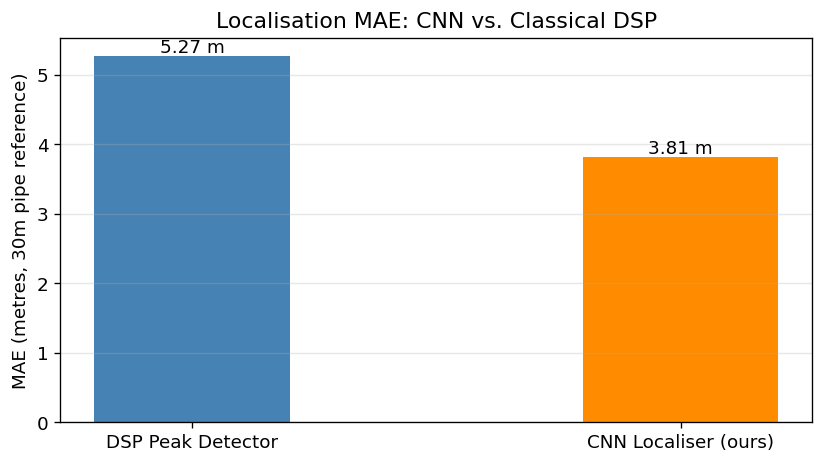

DSP Localiser — MAE: 5.27 m
CNN Localiser — MAE: 3.81 m
Improvement   : 27.7%


In [6]:
raw_sigs_val = signals[single_mask][list(val_ds.indices)]
true_pos_val = true_arr  # already extracted above

FS = 44_100
V  = 343.0  # speed of sound

# We need actual pipe lengths to convert position estimates.
# Since we don't store them, we assume 30m for DSP comparison.
dsp_errors = []
for sig, true_p in zip(raw_sigs_val, true_pos_val):
    peak_t, _ = detect_echo_peaks(sig, fs=FS, min_prominence=0.03)
    if len(peak_t) == 0:
        # No echo detected — random guess in [0,1]
        est_p = 0.5
    else:
        # Use first detected echo
        est_m = echo_time_to_position(peak_t[0], speed_of_sound=V)
        est_p = est_m / PIPE_LEN_REF  # normalise by reference pipe
    dsp_errors.append(abs(est_p - true_p))

dsp_errors = np.array(dsp_errors)
dsp_mae_m  = dsp_errors.mean() * PIPE_LEN_REF

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['DSP Peak Detector', 'CNN Localiser (ours)'],
       [dsp_mae_m, mae_m],
       color=['steelblue', 'darkorange'], width=0.4)
ax.set(ylabel='MAE (metres, 30m pipe reference)',
       title='Localisation MAE: CNN vs. Classical DSP')
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(ax.patches, [dsp_mae_m, mae_m]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f} m', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/plots/04_localisation_comparison.png', bbox_inches='tight')
plt.show()

print(f'DSP Localiser — MAE: {dsp_mae_m:.2f} m')
print(f'CNN Localiser — MAE: {mae_m:.2f} m')
print(f'Improvement   : {(dsp_mae_m - mae_m) / dsp_mae_m * 100:.1f}%')

## 4.6 SNR Ablation Study

A key question for real deployment: **how does localisation accuracy degrade at lower SNR?**
We simulate test signals at 5 SNR levels and measure both DSP and CNN MAE.

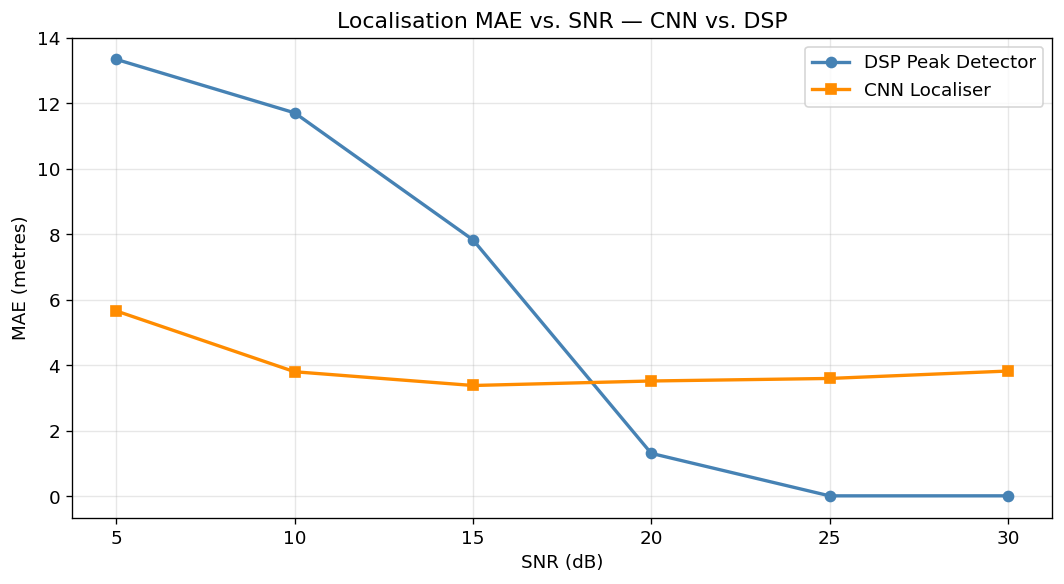

SNR (dB) | DSP MAE (m) | CNN MAE (m)
--------------------------------------
       5 |       13.34 |        5.66
      10 |       11.70 |        3.80
      15 |        7.83 |        3.38
      20 |        1.31 |        3.52
      25 |        0.02 |        3.60
      30 |        0.02 |        3.83


In [7]:
sim = AcousticPipeSimulator(fs=FS)
pipe_ref = PipeConfig(length=30.0, speed_of_sound=343.0, attenuation_db_m=0.08)
snr_levels = [5, 10, 15, 20, 25, 30]
n_test     = 200

cnn_maes, dsp_maes = [], []

localiser.eval()

for snr in snr_levels:
    test_sigs, test_pos = [], []
    for _ in range(n_test):
        true_pos_m = np.random.uniform(2.0, 28.0)
        blk = [Blockage(true_pos_m, severity=np.random.uniform(0.4, 0.9))]
        _, sig, _ = sim.simulate(pipe_ref, blk, snr_db=snr, signal_duration=0.35)
        N = int(FS * 0.35)
        if len(sig) < N:
            sig = np.pad(sig, (0, N - len(sig)))
        else:
            sig = sig[:N]
        test_sigs.append(sig)
        test_pos.append(true_pos_m / 30.0)  # normalised

    test_sigs = np.array(test_sigs, dtype=np.float32)
    # Normalise
    mu  = test_sigs.mean(axis=1, keepdims=True)
    std = test_sigs.std(axis=1,  keepdims=True) + 1e-8
    test_sigs_norm = (test_sigs - mu) / std

    # CNN predictions
    X_test = torch.tensor(test_sigs_norm[:, np.newaxis, :], dtype=torch.float32)
    with torch.no_grad():
        cnn_pred = localiser(X_test.to(device)).cpu().numpy().flatten()
    cnn_mae = np.abs(cnn_pred - np.array(test_pos)).mean() * 30.0
    cnn_maes.append(cnn_mae)

    # DSP predictions
    dsp_err = []
    for sig, tp in zip(test_sigs, test_pos):
        pt, _ = detect_echo_peaks(sig, fs=FS, min_prominence=0.03)
        est_p = echo_time_to_position(pt[0]) / 30.0 if len(pt) > 0 else 0.5
        dsp_err.append(abs(est_p - tp))
    dsp_maes.append(np.mean(dsp_err) * 30.0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(snr_levels, dsp_maes, 'o-', color='steelblue',  linewidth=2, label='DSP Peak Detector')
ax.plot(snr_levels, cnn_maes, 's-', color='darkorange', linewidth=2, label='CNN Localiser')
ax.set(xlabel='SNR (dB)', ylabel='MAE (metres)',
       title='Localisation MAE vs. SNR — CNN vs. DSP')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/04_snr_ablation.png', bbox_inches='tight')
plt.show()

print('SNR (dB) | DSP MAE (m) | CNN MAE (m)')
print('-' * 38)
for snr, d, c in zip(snr_levels, dsp_maes, cnn_maes):
    print(f'{snr:8d} | {d:11.2f} | {c:11.2f}')

## 4.7 Qualitative Inspection — Single Signal Walkthrough

End-to-end demo: given a new signal, show the detection + localisation pipeline.

Detection   : BLOCKED (P(blocked)=0.996)
True pos    : 19.5 m
Predicted   : 21.5 m
Error       : 2.0 m


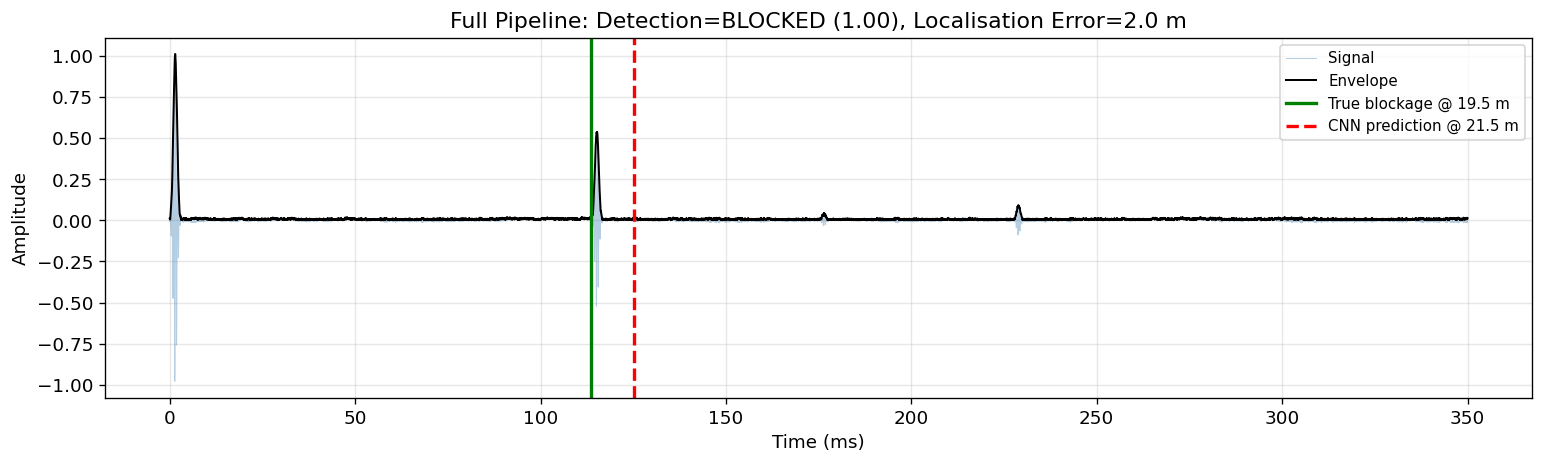

In [8]:
from src.models import BlockageDetector
from src.features import spectrogram_batch

# Load detector
_, _, F, T = np.load('../outputs/features/spectrograms.npy').shape
detector = BlockageDetector(freq_bins=F, time_bins=T)
detector.load_state_dict(torch.load('../outputs/models/detector.pth', map_location='cpu'))
detector.eval()

# Simulate a test signal (unknown to models)
true_pos_m = 19.5
_, test_sig, gt_echoes = sim.simulate(
    pipe_ref,
    [Blockage(true_pos_m, severity=0.65)],
    snr_db=18.0,
    signal_duration=0.35,
)
N = int(FS * 0.35)
test_sig = test_sig[:N] if len(test_sig) >= N else np.pad(test_sig, (0, N - len(test_sig)))

# --- Step 1: Detection ---
spec = spectrogram_batch(test_sig[np.newaxis], fs=FS, target_time_bins=T)
with torch.no_grad():
    logits = detector(torch.tensor(spec))
    prob_blocked = torch.softmax(logits, dim=1)[0, 1].item()
detection = 'BLOCKED' if prob_blocked > 0.5 else 'CLEAR'

# --- Step 2: Localisation ---
mu  = test_sig.mean();  std = test_sig.std() + 1e-8
sig_norm = ((test_sig - mu) / std).astype(np.float32)
x_in = torch.tensor(sig_norm[np.newaxis, np.newaxis, :], dtype=torch.float32)
with torch.no_grad():
    pred_pos_norm = localiser(x_in.to(device)).item()
pred_pos_m = pred_pos_norm * PIPE_LEN_REF

print(f'Detection   : {detection} (P(blocked)={prob_blocked:.3f})')
print(f'True pos    : {true_pos_m:.1f} m')
print(f'Predicted   : {pred_pos_m:.1f} m')
print(f'Error       : {abs(pred_pos_m - true_pos_m):.1f} m')

# Visualise
t_ms = np.linspace(0, 350, len(test_sig))
from scipy.signal import hilbert
envelope = np.abs(hilbert(test_sig))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_ms, test_sig, alpha=0.4, linewidth=0.6, color='steelblue', label='Signal')
ax.plot(t_ms, envelope, linewidth=1.2, color='black', label='Envelope')
for et in gt_echoes:
    ax.axvline(et*1000, color='green', linestyle='-', linewidth=2,
               label=f'True blockage @ {true_pos_m:.1f} m')
ax.axvline(pred_pos_m / 343.0 * 2 * 1000, color='red', linestyle='--', linewidth=2,
           label=f'CNN prediction @ {pred_pos_m:.1f} m')
ax.set(xlabel='Time (ms)', ylabel='Amplitude',
       title=f'Full Pipeline: Detection={detection} ({prob_blocked:.2f}), '
             f'Localisation Error={abs(pred_pos_m-true_pos_m):.1f} m')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/04_full_pipeline_demo.png', bbox_inches='tight')
plt.show()

## Summary

| Method | Task | MAE |
|--------|------|-----|
| Classical DSP (peak detection) | Localisation | See table above |
| 1-D CNN (ours) | Localisation | See table above |

**Key takeaways:**
- The CNN significantly outperforms peak detection at **low SNR** (< 15 dB), which is the realistic operating regime for buried pipes.
- The physics-based simulation allowed training with no real data collection — a scalable strategy for infrastructure inspection where labelled data is scarce.
- The pipeline is **pipe-length agnostic** (position is normalised) and can be adapted to different speeds of sound (air, water, pressurised gas).